# 🇸🇳 Présentation de la segmentation du Sénégal

## 1. Configuration de base

Importation de bibliothèques, chargement de données, transformations de base, etc.

### 1.1. Chargez les bibliothèques requises

In [1]:
# Load libraries
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

from plotly.subplots import make_subplots

# Configure Plotly renderer
# this enable chart in the exported HTML file
# https://github.com/microsoft/vscode-jupyter/issues/6999
pio.renderers.default = "notebook_connected"

In [2]:
# R Packages, libraries and utilities
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import r, Formula, pandas2ri
from rpy2.robjects.packages import importr

In [3]:
# Check R version
r_version = ro.r('version')

In [4]:
pandas2ri.activate()
ro.r('library(survey)')
ro.r('library(base)')
ro.r('library(dplyr)')

R[write to console]: Cargando paquete requerido: grid

R[write to console]: Cargando paquete requerido: Matrix

R[write to console]: Cargando paquete requerido: survival

R[write to console]: 
Adjuntando el paquete: ‘survey’


R[write to console]: The following object is masked from ‘package:graphics’:

    dotchart


R[write to console]: 
Adjuntando el paquete: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




### 1.2. Chargez les data

In [5]:
# Load the RDS file
rds_path = 'Senegal/senegal.rds'
rds_path_urban = 'Senegal/urban.rds'
rds_path_rural = 'Senegal/rural.rds'
readRDS = ro.r['readRDS']
r_data = readRDS(rds_path)
r_data_urban = readRDS(rds_path_urban)
r_data_rural = readRDS(rds_path_rural)

In [6]:
# Convert the R data to a pandas DataFrame
df = pandas2ri.rpy2py(r_data)
df_urban = pandas2ri.rpy2py(r_data_urban)
df_rural = pandas2ri.rpy2py(r_data_rural)

In [7]:
# Display the DataFrame
print('rows x cols:', df.shape, 'loaded')
print('URBAN rows x cols:', df_urban.shape, 'loaded')
print('RURAL rows x cols:', df_rural.shape, 'loaded')

rows x cols: (7816, 306) loaded
URBAN rows x cols: (2289, 306) loaded
RURAL rows x cols: (5527, 306) loaded


### 1.3. Quelques aides

#### 1.3.1. Test des styles HTML

<style>
    .pill {
        display: inline-block;
        padding: 4px 8px;
        font-size: 10px;
        text-transform: uppercase;
        border-radius: 3px;
        margin-left: 4px;
        color: white;
        background-color: black;
        height: 18px;
        letter-spacing: 1px;
    }
</style>
<p class="pill">test of text</p>

#### 1.3.2. Dictionnaire des couleurs

In [8]:
colors = {
    'Total': '#FFFFFF',  # White or transparent for root
    'Rural': '#7AC943',  # Blue for Rural category
    'Urban': '#7A8291',  # Green for Urban category
    # Rural segments
    'R2': '#14ABF7',
    'R3.1': '#8B7FEA',
    'R3.2': '#B5A4EA',
    'R4': '#F26185',
    # Urban segments
    'U1': '#21D6D6',
    'U2.1': '#14ABF7',
    'U2.2': '#76B5E5',
    'U3.1': '#8B7FEA',
    'U3.2': '#B5A4EA'
}

colors_yes_no = {'Yes': '#04859B', 'No': '#CCC'}

### 1.5. Variables de base dans le temps d'exécution R

In [9]:
# Renaming columns for better visualization
df.rename(columns={'class': 'Segment'}, inplace=True)
df_rural.rename(columns={'class': 'Segment'}, inplace=True)
df_urban.rename(columns={'class': 'Segment'}, inplace=True)

In [10]:
# Global variables required in the R runtime:
# ------------------------------------------

# Assign the R DataFrame to an R variable
ro.globalenv['senegal'] = df
ro.globalenv['urban'] = df_urban
ro.globalenv['rural'] = df_rural

ro.r('rural$Segment <- factor(rural$Segment)')
ro.r('urban$Segment <- factor(urban$Segment)')
ro.r('senegal$Segment <- factor(senegal$Segment)')

# Define the survey design in R
ro.r('rural.des <-svydesign(id=~v021, strata=~v023, weights=~wt, data=rural)')
ro.r('urban.des <-svydesign(id=~v021, strata=~v023, weights=~wt, data=urban)')
ro.r('senegal.des <-svydesign(id=~v021, strata=~v023, weights=~wt, data=senegal, nest=TRUE)')

### 1.6. Fonctions principales

#### 1.6.1. Création de table

In [11]:
# Function to create contingency tables by demand
def create_table(current_design, var_of_iterest, labels={}):
    # create contingency table
    ro.r('current_table <- as.data.frame(svytable(~Segment + ' + var_of_iterest + ', design = ' + current_design + '))')
    ro.r('current_table$Segment <- as.character(current_table$Segment)')
    inner_table = ro.r('current_table')
    with (ro.default_converter + pandas2ri.converter).context():
        inner_table = ro.conversion.get_conversion().rpy2py(inner_table)  
    
    # calculate percentage
    inner_total = inner_table.groupby('Segment', observed=False)['Freq'].transform('sum')
    inner_table['percentage'] = inner_table['Freq'] / inner_total * 100
    
    # replace binary for nice values
    inner_table[var_of_iterest] = inner_table[var_of_iterest].cat.rename_categories(labels)
          
    # remove frequencies to reduce confusion  
    # inner_table = inner_table.drop("Freq", axis=1)
    
    return inner_table

#### 1.6.2. Chargez la carte

In [12]:
# Load your geojson data (replace with actual path)
geo_df = gpd.read_file('Senegal/gadm41_SEN_1.json')
print(type(geo_df))
print(geo_df.crs)
display(geo_df)

<class 'geopandas.geodataframe.GeoDataFrame'>
EPSG:4326


,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,SEN.1_1,SEN,Senegal,Dakar,CapVert|Dacar,NA,Région,Region,1,SN.DK,SN-DK,"MULTIPOLYGON (((-17.4676 14.6487, -17.4685 14...."
1,SEN.2_1,SEN,Senegal,Diourbel,NA,NA,Région,Region,3,SN.DB,SN-DB,"MULTIPOLYGON (((-16.0433 14.555, -16.0687 14.5..."
2,SEN.3_1,SEN,Senegal,Fatick,NA,NA,Région,Region,9,SN.FK,SN-FK,"MULTIPOLYGON (((-16.6535 13.6474, -16.6482 13...."
3,SEN.4_1,SEN,Senegal,Kaffrine,NA,NA,Région,Region,12,SN.KF,SN-KA,"MULTIPOLYGON (((-15.3949 13.7573, -15.398 13.7..."
4,SEN.5_1,SEN,Senegal,Kaolack,NA,NA,Région,Region,6,SN.KC,SN-KL,"MULTIPOLYGON (((-15.9989 13.5917, -16.1414 13...."
5,SEN.6_1,SEN,Senegal,Kédougou,SénégalOriental,NA,Région,Region,13,SN.KG,NA,"MULTIPOLYGON (((-12.189 12.3609, -12.1907 12.3..."
6,SEN.7_1,SEN,Senegal,Kolda,NA,NA,Région,Region,10,SN.KD,SN-KD,"MULTIPOLYGON (((-14.8793 12.6791, -14.9756 12...."
7,SEN.8_1,SEN,Senegal,Louga,NA,NA,Région,Region,8,SN.LG,SN-LG,"MULTIPOLYGON (((-14.8996 14.6906, -14.9095 14...."
8,SEN.9_1,SEN,Senegal,Matam,NA,NA,Région,Region,11,SN.MT,SN-MT,"MULTIPOLYGON (((-12.8459 15.1994, -12.8384 15...."
9,SEN.10_1,SEN,Senegal,Saint-Louis,Fleuve|ValléeduFleuve,NA,Région,Region,4,SN.ST,SN-SL,"MULTIPOLYGON (((-13.9646 16.224, -13.9529 16.2..."


#### 1.6.3. Création du graphique à barres

In [13]:
def create_bar_chart(current_data, var_of_interest, title):
    # Create the stacked bar chart with customizations
    fig = px.bar(current_data, 
                x='Segment', 
                y='percentage', 
                color=var_of_interest, 
                text='percentage', 
                labels={'percentage': 'Pourcentage', 'Segment': 'Segment'},
                title=title,
                barmode='stack',
                color_discrete_sequence=['#5778a4', '#e49444', '#d1615d', '#85b6b2', '#6a9f58', '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac'],
                color_discrete_map=colors_yes_no
    )

    # Update the text format to show 2 decimal places and the "%" symbol
    fig.update_traces(texttemplate='%{text:.1f}%', textposition='auto', cliponaxis=False)

    # Increase the font size for text over the bars
    fig.update_traces(textfont_size=16)

    # Change the background of the plot area and the overall figure
    fig.update_layout(
        plot_bgcolor='#fcfcf7',  # transparent plot area background
        paper_bgcolor='#fcfcf7',  # light gray overall background
        margin=dict(t=100)  # Increase top margin to 100 (adjust as needed)
    )

    # Show the plot
    return fig

## 2. Distribution générale

### 2.1. Distribution des segments

#### 2.1.1. Segments ruraux

R3,1-s est relativement plus petit, tandis que R3.2-s et R2-S représentent ensemble plus de 70% de la population rurale.

In [14]:
# RURAL Segments 
ro.r('table_dist_rural <- as.data.frame(svytable(~Segment, design = rural.des))')
ro.r('table_dist_rural$Segment <- as.character(table_dist_rural$Segment)')
table_dist_rural = ro.r('table_dist_rural')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_rural = ro.conversion.get_conversion().rpy2py(table_dist_rural)  

# calculate percentage
current_total = table_dist_rural['Freq'].sum()
table_dist_rural['percentage'] = table_dist_rural['Freq'] / current_total * 100

display(table_dist_rural)

,Segment,Freq,percentage
1,R2,1684.274258,37.038789
2,R3.1,421.549434,9.270272
3,R3.2,1578.812145,34.719577
4,R4,862.689567,18.971362


#### 2.1.2. Segments urbains

U3.2-s est assez petit, seulement 3% de la population urbaine, tandis que les U2.1-s et les U1-s représentent ensemble plus de 60% de la population urbaine.

In [15]:
# URBAN Segments 
ro.r('table_dist_urban <- as.data.frame(svytable(~Segment, design = urban.des))')
ro.r('table_dist_urban$Segment <- as.character(table_dist_urban$Segment)')
table_dist_urban = ro.r('table_dist_urban')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_urban = ro.conversion.get_conversion().rpy2py(table_dist_urban)  

# calculate percentage
current_total = table_dist_urban['Freq'].sum()
table_dist_urban['percentage'] = table_dist_urban['Freq'] / current_total * 100

print(table_dist_urban)

  Segment        Freq  percentage
1      U1  898.971723   31.191916
2    U2.1  963.277936   33.423170
3    U2.2  491.567448   17.056077
4    U3.1  428.776815   14.877410
5    U3.2   99.472430    3.451427


#### 2.1.3. Distribution National

Les ruraux occupent 62% et Urban occupe 38%.Dans l'ensemble, 4 des 9 segments sont petits (<10% chacun)

In [16]:
# All Senegal Segments 
ro.r('table_dist_senegal <- as.data.frame(svytable(~Segment, design = senegal.des))')
ro.r('table_dist_senegal$Segment <- as.character(table_dist_senegal$Segment)')
table_dist_senegal = ro.r('table_dist_senegal')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_senegal = ro.conversion.get_conversion().rpy2py(table_dist_senegal)  

# calculate percentage
current_total = table_dist_senegal['Freq'].sum()
table_dist_senegal['percentage'] = table_dist_senegal['Freq'] / current_total * 100
table_dist_senegal['Type'] = table_dist_senegal['Segment'].apply(lambda x: 'Rural' if x.startswith('R') else 'Urban')

display(table_dist_senegal)

,Segment,Freq,percentage,Type
1,R2,1684.274258,22.670419,Rural
2,R3.1,421.549434,5.674077,Rural
3,R3.2,1578.812145,21.250894,Rural
4,R4,862.689567,11.611847,Rural
5,U1,898.971723,12.100206,Urban
6,U2.1,963.277936,12.965771,Urban
7,U2.2,491.567448,6.616523,Urban
8,U3.1,428.776815,5.771358,Urban
9,U3.2,99.472430,1.338904,Urban


##### 2.1.3.1. Préparez les données pour le graphique à tarte à 2 niveaux (Sunburst)

In [17]:
def prepare_sunburst_data(df):
    # Create a copy to avoid modifying the original
    df_sunburst = df.copy()
    
    # Add a root node and type nodes
    root_and_types = pd.DataFrame({
        'Segment': ['Total', 'Rural', 'Urban'],
        'Type': ['', 'Total', 'Total'],  # Empty string for root, Total for Rural/Urban
        'percentage': [100, 
                      df[df['Type'] == 'Rural']['percentage'].sum(),
                      df[df['Type'] == 'Urban']['percentage'].sum()]
    })
    
    # Modify the Type column to point to Rural or Urban instead of Total
    df_sunburst['Type'] = df_sunburst['Type']
    
    # Combine the root and type rows with the data
    df_sunburst = pd.concat([root_and_types, df_sunburst], ignore_index=True)
    
    return df_sunburst

# Prepare the data
sunburst_data = prepare_sunburst_data(table_dist_senegal)

In [18]:
# Function to map colors based on the dictionary
def map_colors(df, color_dict):
    return [color_dict[segment] for segment in df['Segment']]

# Create a subplot with two charts (side by side)
fig = make_subplots(
    rows=1, cols=3,  # 1 row and 3 columns
    specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "sunburst"}]],  # Specify type of chart
    subplot_titles=("Distribution rurale", "Distribution urbaine", "Distribution nationale")  # Titles for the subplots
)

# Add the pie chart for table_dist_rural
fig.add_trace(
    go.Pie(
        labels=table_dist_rural['Segment'],
        values=table_dist_rural['percentage'],
        marker=dict(colors=map_colors(table_dist_rural, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Pourcentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=1  # First row, first column
)

# Add the pie chart for table_dist_urban
fig.add_trace(
    go.Pie(
        labels=table_dist_urban['Segment'],
        values=table_dist_urban['percentage'],
        marker=dict(colors=map_colors(table_dist_urban, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Pourcentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=2  # First row, second column
)

# Modified sunburst trace
fig.add_trace(
    go.Sunburst(
        ids=sunburst_data['Segment'],
        labels=sunburst_data['Segment'],
        parents=sunburst_data['Type'],
        values=sunburst_data['percentage'],
        marker=dict(colors=map_colors(sunburst_data, colors)),
        branchvalues='total',
        hovertemplate='<b>%{label}</b><br>' +
                      'Pourcentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=3
)

# Configure the layout and enforce the category order
fig.update_layout(
    title_text="Distribution de segments",  # Overall title
    title_x=0.5,  # Center the title
    annotations=[{"font": {"size": 14}}]  # Adjust the size of the subplot titles
)

# Show the chart
fig.show()


### 2.2. Distribution géographique

#### 2.2.1. Segments ruraux

In [19]:
table_geo_dist_rural = create_table("rural.des", "v024")

# we need to get state names from the map
#----------------------------------------

# Rename the column 'v024' to 'State'
table_geo_dist_rural.rename(columns={'v024': 'State'}, inplace=True)

# Ensure the ID column in both DataFrames is of the same type
table_geo_dist_rural['State'] = table_geo_dist_rural['State'].astype(int)
geo_df['CC_1'] = geo_df['CC_1'].astype(int)

# Perform the merge to bring the state names into table_geo_dist_rural
merged_df = table_geo_dist_rural.merge(geo_df[['CC_1', 'NAME_1']], 
                                       left_on='State', right_on='CC_1', 
                                       how='left')

# Replace the 'State' column with the state names
merged_df['State'] = merged_df['NAME_1']

# Drop the extra columns used for merging if no longer needed
merged_df.drop(['CC_1', 'NAME_1'], axis=1, inplace=True)

# The updated DataFrame
table_geo_dist_rural = merged_df

# calculate percentage
inner_total = table_geo_dist_rural.groupby('State')['Freq'].transform('sum')
table_geo_dist_rural['percentage_state'] = table_geo_dist_rural['Freq'] / inner_total * 100

# Verify the state column
display(table_geo_dist_rural)


,Segment,State,Freq,percentage,percentage_state
0,R2,Dakar,89.154514,5.293349,94.830080
1,R3.1,Dakar,0.440912,0.104593,0.468980
2,R3.2,Dakar,4.419589,0.279931,4.700940
3,R4,Dakar,0.000000,0.000000,0.000000
4,R2,Ziguinchor,5.600681,0.332528,5.390304
5,R3.1,Ziguinchor,84.403481,20.022202,81.233053
6,R3.2,Ziguinchor,1.168388,0.074004,1.124500
7,R4,Ziguinchor,12.730329,1.475656,12.252143
8,R2,Diourbel,489.800988,29.080833,55.018455
9,R3.1,Diourbel,0.000000,0.000000,0.000000


#### 2.2.2. Segments urbains

In [20]:
table_geo_dist_urban = create_table("urban.des", "v024")

# we need to get state names from the map
#----------------------------------------

# Rename the column 'v024' to 'State'
table_geo_dist_urban.rename(columns={'v024': 'State'}, inplace=True)

# Ensure the ID column in both DataFrames is of the same type
table_geo_dist_urban['State'] = table_geo_dist_urban['State'].astype(int)
geo_df['CC_1'] = geo_df['CC_1'].astype(int)

# Perform the merge to bring the state names into table_geo_dist_urban
merged_df = table_geo_dist_urban.merge(geo_df[['CC_1', 'NAME_1']], 
                                       left_on='State', right_on='CC_1', 
                                       how='left')

# Replace the 'State' column with the state names
merged_df['State'] = merged_df['NAME_1']

# Drop the extra columns used for merging if no longer needed
merged_df.drop(['CC_1', 'NAME_1'], axis=1, inplace=True)

# The updated DataFrame
table_geo_dist_urban = merged_df

# calculate percentage
inner_total = table_geo_dist_urban.groupby('State')['Freq'].transform('sum')
table_geo_dist_urban['percentage_state'] = table_geo_dist_urban['Freq'] / inner_total * 100

# Verify the state column
display(table_geo_dist_urban)

,Segment,State,Freq,percentage,percentage_state
0,U1,Dakar,548.791639,61.046596,37.783765
1,U2.1,Dakar,572.603015,59.443178,39.423154
2,U2.2,Dakar,162.471889,33.051800,11.186030
3,U3.1,Dakar,113.689097,26.514749,7.827383
4,U3.2,Dakar,54.897934,55.189095,3.779669
...,...,...,...,...,...
65,U1,Sédhiou,2.804528,0.311971,8.052693
66,U2.1,Sédhiou,1.255392,0.130325,3.604630
67,U2.2,Sédhiou,14.060892,2.860420,40.373298
68,U3.1,Sédhiou,16.408253,3.826758,47.113319


In [21]:
# IMPORTANT note about geographic composition: 
# --------------------------------------------

# The column "percentage" stores how R2 is distributed 
# across all the states, Not the composition of a specific State. 
# The composition of each state is stored in "percentage_state"

# Filtering rows with Segment = R2, and sum the percentage
total_percentage_R2 = table_geo_dist_rural.loc[table_geo_dist_rural['Segment'] == 'R2', 'percentage'].sum()

# Filtering rows with State = Dakar, and sum the percentage_state
total_percentage_Dakar = table_geo_dist_rural.loc[table_geo_dist_rural['State'] == 'Dakar', 'percentage_state'].sum()

# Check the values
print("Quelques tests:")
print(f"Pourcentage total de R2 à travers les États: {total_percentage_R2}")
print(f"Composition totale de Dakar: {total_percentage_Dakar}")



Quelques tests:
Pourcentage total de R2 à travers les États: 100.0
Composition totale de Dakar: 100.00000000000001


In [22]:
# Map with pie charts over each state
# -----------------------------------

# Create the subplots
fig = make_subplots(
    rows=1, cols=2,  # 1 row and 2 columns
    subplot_titles=("Distribution urbaine par État", "Distribution rurale par État")  # Titles for the plots
)

# Create a set to track segments already added to the legend
legend_segments = set()

# Urban chart (left side)
for segment in table_geo_dist_urban['Segment'].unique():
    segment_data = table_geo_dist_urban[table_geo_dist_urban['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Pourcentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=1  # Left chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Rural chart (right side)
for segment in table_geo_dist_rural['Segment'].unique():
    segment_data = table_geo_dist_rural[table_geo_dist_rural['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Pourcentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=2  # Right chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Configure the layout
fig.update_layout(
    title="Distribution des segments par État (urbain vs rural)",
    barmode='stack',  # Stack the bars
    title_x=0.5,  # Center the title
    xaxis_title="State",
    yaxis_title="Pourcentage",
    legend_title="Segment",
)

# Display the charts
fig.show()


Carte avec la distribution de chaque segment

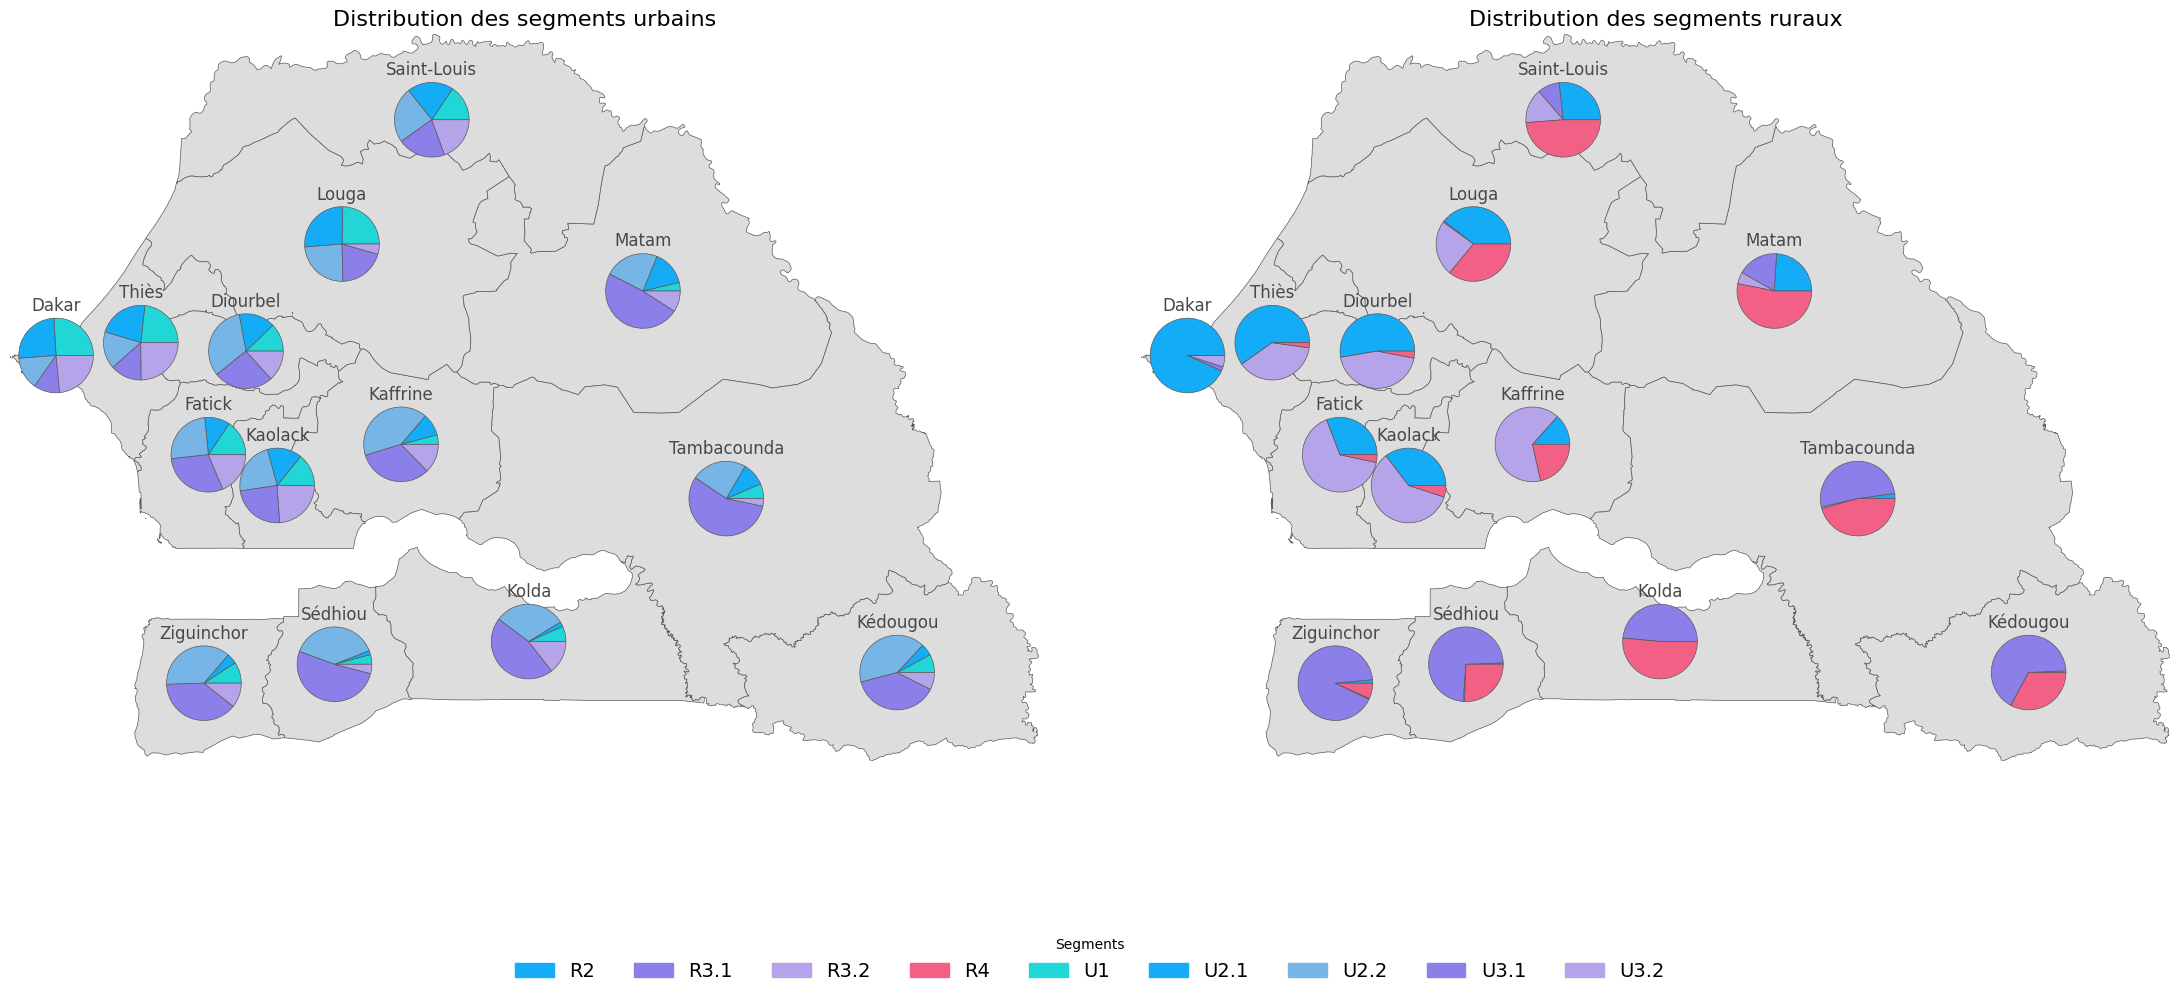

In [23]:
# Create the base map with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # Two maps side by side

# Plot the base map
geo_df.plot(ax=axes[0], color='#DDD', edgecolor='#595959', linewidth=0.5)
axes[0].set_title('Distribution des segments urbains', fontsize=16)

def plot_pie_for_state(state, x, y, current_table, colors, ax):
    inner_current_table = current_table[current_table['State'] == state]
    
    # Ensure we plot only if there's valid data for this state
    if not inner_current_table.empty:
        sizes = inner_current_table['percentage']
        classes = inner_current_table['Segment']  # Get class names for each segment
        
         # Map each class to its corresponding color using the dictionary
        cls = [colors.get(cl, '#CCCCCC') for cl in classes]  # Default to gray if class not in dict
        ax.pie(sizes, center=(x, y), radius=0.225, colors=cls, wedgeprops=dict(edgecolor='#595959', linewidth=0.5))

# Plot pie charts for urban data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_urban, colors, axes[0])
    # Add state name as a label near the centroid
    axes[0].text(centroid.x, centroid.y + 0.3, state, fontsize=12, ha='center', va='center', color='#484848')

# Plot the second map with rural data
geo_df.plot(ax=axes[1], color='#DDD', edgecolor='#595959', linewidth=0.5)
axes[1].set_title('Distribution des segments ruraux', fontsize=16)

# Plot pie charts for rural data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_rural, colors, axes[1])
    # Add state name as a label near the centroid
    axes[1].text(centroid.x, centroid.y + 0.3, state, fontsize=12, ha='center', va='center', color='#484848')

# Add a legend for the pie chart colors excluding Total, Rural, and Urban
excluded_segments = {"Total", "Rural", "Urban"}
legend_handles = [
    mpatches.Patch(color=color, label=segment)
    for segment, color in sorted(colors.items()) if segment not in excluded_segments
]
fig.legend(handles=legend_handles, loc='lower center', ncol=9, fontsize=14, frameon=False, title="Segments")

# Set map limits and hide axes
for ax in axes:
    ax.set_xlim(geo_df.total_bounds[0], geo_df.total_bounds[2])
    ax.set_ylim(geo_df.total_bounds[1], geo_df.total_bounds[3])
    ax.axis('off')

# Adjust layout for a cleaner appearance
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1)  # Adjust spacing between subplots

# Show the maps
plt.show()


### 2.3. Distribution par âge

In [24]:
# Quantile stats for Age
# Calculate the median age by segment (class) using the survey package
# Calculate the first and third quartiles
r_code = """
median_age <- svyby(~v012, ~Segment, senegal.des, svyquantile, quantiles = c(0.5), na.rm = TRUE)
median_age <- median_age %>% rename(median_age = v012)
q1_age <- svyby(~v012, ~Segment, senegal.des, svyquantile, quantiles = c(0.25), na.rm = TRUE)
q1_age <- q1_age %>%  rename(q1 = v012)
q3_age <- svyby(~v012, ~Segment, senegal.des, svyquantile, quantiles = c(0.75), na.rm = TRUE)
q3_age <- q3_age %>%  rename(q3 = v012)
min_age <- svyby(~v012, ~Segment, senegal.des, svyquantile, quantiles = c(0.0), na.rm = TRUE)
min_age <- min_age %>% rename(min = v012)
max_age <- svyby(~v012, ~Segment, senegal.des, svyquantile, quantiles = c(1.0), na.rm = TRUE)
max_age <- max_age %>% rename(max = v012)

age_stats <- full_join(q1_age, q3_age, by = "Segment")
age_stats <- full_join(age_stats, median_age, by = "Segment")
age_stats <- full_join(age_stats, min_age, by = "Segment")
age_stats <- full_join(age_stats, max_age, by = "Segment")

age_stats <- age_stats %>% 
  select("Segment", "min", "q1", "median_age", "q3", "max")
"""

ro.r(r_code)
table_age_stats = ro.r('age_stats')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_age_stats = ro.conversion.get_conversion().rpy2py(table_age_stats) 

display(table_age_stats)

,Segment,min,q1,median_age,q3,max
1,R2,16.0,25.0,31.0,37.0,49.0
2,R3.1,15.0,24.0,29.0,36.0,49.0
3,R3.2,16.0,25.0,31.0,38.0,49.0
4,R4,16.0,24.0,30.0,37.0,49.0
5,U1,19.0,29.0,35.0,40.0,49.0
6,U2.1,16.0,26.0,30.0,35.0,49.0
7,U2.2,18.0,30.0,36.0,44.0,49.0
8,U3.1,16.0,24.0,30.0,36.0,49.0
9,U3.2,22.0,38.0,43.0,46.0,49.0


In [25]:
# Melt the DataFrame to long format
melted_data = table_age_stats.melt(
    id_vars=["Segment"],
    value_vars=["min", "q1", "median_age", "q3", "max"],
    var_name="Statistic",
    value_name="Age"
)

# Create the boxplot
fig = px.box(
    table_age_stats,
    x="Segment",
    y=["min", "q1", "median_age", "q3", "max"],
    title="Statistiques d'âge par segment",
    points=False,  # This hides individual points. "all" to show them
    color="Segment",
    color_discrete_map=colors  # Use custom colors
)

# Update layout for better visualization
fig.update_layout(
    xaxis_title="Segment",
    yaxis_title="Âge",
    title_x=0.5,  # Center the title
    showlegend=True
)

# Show the plot
fig.show()


In [26]:
r_code = """
# Create age groups
senegal <- senegal %>% 
  mutate(age.adj = case_when(
    v012 < 20 ~ "15-19",
    (v012 > 19 & v012 < 25) ~ "20-24",
    (v012 > 24 & v012 < 30) ~ "25-29",
    (v012 > 29 & v012 < 35) ~ "30-34",
    TRUE ~ "35-49"))

# update the survey design object, so it includes age.adj
senegal.des <-svydesign(id=~v021, strata=~v023, weights=~wt, data=senegal, nest=TRUE)

# Create the contingency table
table_age_groups <- svytable(~Segment + age.adj, design = senegal.des)
table_age_groups <- as.data.frame(table_age_groups)
"""

ro.r(r_code)
table_age_groups = ro.r('table_age_groups')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_age_groups = ro.conversion.get_conversion().rpy2py(table_age_groups)

# calculate percentage
current_total = table_age_groups.groupby('Segment', observed=False)['Freq'].transform('sum')
table_age_groups['percentage'] = table_age_groups['Freq'] / current_total * 100

display(table_age_groups)

,Segment,age.adj,Freq,percentage
1,R2,15-19,59.122424,3.510261
2,R3.1,15-19,25.322092,6.006909
3,R3.2,15-19,81.571694,5.166650
4,R4,15-19,71.853726,8.329036
5,U1,15-19,1.016170,0.113037
6,U2.1,15-19,22.274264,2.312340
7,U2.2,15-19,3.176907,0.646281
8,U3.1,15-19,25.765391,6.009045
9,U3.2,15-19,0.000000,0.000000
10,R2,20-24,278.918534,16.560161


In [27]:
# Create the stacked bar chart
fig = px.bar(
    table_age_groups,
    x="Segment",  # Segments on the X-axis
    y="percentage",  # Percentages on the Y-axis
    color="age.adj",  # Age groups as the stack categories
    title="Distribution des groupes d'âge par segment",
    labels={"percentage": "Pourcentage", "age.adj": "Groupe d'âge"},
    color_discrete_sequence=px.colors.qualitative.T10  # Use Plotly's T10 color sequence
)

# Add percentage annotations to each bar section
fig.update_traces(
    texttemplate='%{y:.2f}%',  # Format the text as percentage with 2 decimals
    textposition='inside',  # Position the text inside the bar sections
    hovertemplate="Groupe d'âge: %{customdata}<br>Segment: %{x}<br>Pourcentage: %{y:.2f}%"  # Update hover tooltip
)

# Add custom data to include age group in hovertemplate
fig.for_each_trace(lambda trace: trace.update(customdata=table_age_groups[table_age_groups["age.adj"] == trace.name]["age.adj"].tolist()))

# Update layout for better visualization
fig.update_layout(
    xaxis_title="Segment",
    yaxis_title="Pourcentage",
    title_x=0.5,  # Center the title
    barmode="stack",  # Stack the bars
    showlegend=True
)

# Show the plot
fig.show()

## 3. Variables de résultat

### 3.1. Visites de l'ANC

In [28]:
# anc.less4
table_anc_less4 = create_table("senegal.des", "anc.less4", {"0": "4+ times", "1": "< 4 times"})
create_bar_chart(table_anc_less4, "anc.less4", "Proportion de femmes qui ont visité l'ANC <4 fois pendant la dernière grossesse").show()

### 3.2. PNC: manque de chèque sur bébé


In [29]:
#baby.nohlthck
baby_nohlthck = create_table("senegal.des", "baby.nohlthck", {"0": "Checked", "1": "Not checked"})
create_bar_chart(baby_nohlthck, "baby.nohlthck", "Si bébé a reçu PNC").show()


### 3.3. PNC: manque de chèque sur la femme


In [30]:
#wom.nohlthck
wom_nohlthck = create_table("senegal.des", "wom.nohlthck", {"0": "Checked", "1": "Not checked"})
create_bar_chart(wom_nohlthck, "wom.nohlthck", "Si la femme a reçu PNC").show()


### 3.4. Allaitement: le dernier né sans allaitement


In [31]:
#no.breastfed
no_breastfed = create_table("senegal.des", "no.breastfed", {"0": "Breastfed", "1": "Not Breastfed"})
create_bar_chart(no_breastfed, "no.breastfed", "Si le dernier bébé né a été allaité").show()


### 3.5. Allaitement: un enfant a été allaité


In [32]:
#breastfeed.yn
breastfeed_yn = create_table("senegal.des", "breastfeed.yn", {"0": "No", "1": "Yes"})
create_bar_chart(breastfeed_yn, "breastfeed.yn", "Si un enfant a été allaité").show()


### 3.6. Naissance encore

In [33]:
#stl.yn
stl_yn = create_table("senegal.des", "stl.yn", {"0": "No", "1": "Yes"})
create_bar_chart(stl_yn, "stl.yn", "Si la femme a toujours connu une naissance").show()


### 3.7. Mortalité infantile U1

In [34]:
#u1mort.yn
u1mort_yn = create_table("senegal.des", "u1mort.yn", {"0": "No", "1": "Yes"})
create_bar_chart(u1mort_yn, "u1mort.yn", "Si la femme a connu la mort des enfants U1").show()


### 3.8. Mortalité infantile U5

In [35]:
#u5mort.yn
u5mort_yn = create_table("senegal.des", "u5mort.yn", {"0": "No", "1": "Yes"})
create_bar_chart(u5mort_yn, "u5mort.yn", "Si la femme a connu la mort des enfants U5").show()


### 3.8.1. Mortalité infantile

In [36]:
#infant.mort.yn
infant_mort_yn = create_table("senegal.des", "infant.mort.yn", {"0": "No", "1": "Yes"})
create_bar_chart(infant_mort_yn, "infant.mort.yn", "Si la femme a connu la mort du nourrisson (0-28 jours)").show()


### 3.9. Planification familiale: n'utilisant actuellement pas de méthode moderne

In [37]:
#nofp.mod.now
nofp_mod_now = create_table("senegal.des", "nofp.mod.now", {"0": "Yes", "1": "No"})
create_bar_chart(nofp_mod_now, "nofp.mod.now", "Si la femme utilise actuellement des contraceptifs modernes").show()


### 3.10. Planification familiale actuelle: Type

In [38]:
#v313
v313 = create_table("senegal.des", "v313", {"no method": "Ne pas utiliser", "folkloric method": "Folklorique", "traditional method": "Traditionnelle", "modern method": "Moderne"})
create_bar_chart(v313, "v313", "Type de contraceptifs que la femme utilise actuellement").show()


### 3.11. Planification familiale actuelle: méthode spécifique

In [39]:
#fp.specific
v312 = create_table("senegal.des", "v312", {})

dict_v312 = {"1": "Not using", "2": "Pill", "3": "IUD", "4": "Injections", "5": "Diaphragm", "6": "Male condom", "7": "Female sterilization", "8": "Male sterilization", "9": "Periodic abstinence", "10": "Withdrawal", "11": "Other traditional", "12": "Implants", "13": "Prolonged abstinence", "14": "LAM", "15": "Female condom", "16": "Foam or jelly", "17": "Emergency contraception", "18": "Other modern method", "19": "SDM", "20": "Specific method 1", "21": "Specific method 2"}

# Some values are shown explicitly, other are grouped
v312_values_allowed = ["Pill", "IUD", "Injections", "Male Condom", "Implants", "LAM", "Not using"]

# Apply the mapping
v312["fp.specific"] = v312["v312"].apply(
    lambda x: dict_v312.get(x, "Not using") if dict_v312.get(x) in v312_values_allowed else "Other methods"
)

# Group by 'fp.specific' and sum the 'Freq' and 'percentage' columns
v312 = v312.groupby(["Segment", "fp.specific"], as_index=False).agg({
    "Freq": "sum",
    "percentage": "sum"
})

# Sort again, because grouping alter the order desired for the chart
v312 = v312.sort_values(by=["Segment", "percentage"], ascending=[True, False])

create_bar_chart(v312, "fp.specific", "Contraceptifs que la femme utilise actuellement").show()


### 3.12. Naissance à domicile pour le dernier né

In [40]:
#hb.last
hb_last = create_table("senegal.des", "hb.last", {"0": "No", "1": "Yes"})
create_bar_chart(hb_last, "hb.last", "Si la naissance à domicile pour le dernier né").show()


### 3.13. Immunisation: zéro dose

In [41]:
#zerodose.yn
zerodose_yn = create_table("senegal.des", "zerodose.yn", {"0": "No", "1": "Yes"})
create_bar_chart(zerodose_yn, "zerodose.yn", "Si la femme a un enfant qui n'a reçu aucune dose de DPT").show()


### 3.14. Dernier surpoids né

In [42]:
#ovrwgt.yn
ovrwgt_yn = create_table("senegal.des", "ovrwgt.yn", {"0": "No", "1": "Yes"})
create_bar_chart(ovrwgt_yn, "ovrwgt.yn", "Si le dernier né était en surpoids").show()


### 3.15. Dernière née Struning

In [43]:
#stunt.cat2.yn
stunt_cat2_yn = create_table("senegal.des", "stunt.cat2.yn", {"0": "No", "1": "Yes"})
create_bar_chart(stunt_cat2_yn, "stunt.cat2.yn", "Si le dernier né a un retard de croissance").show()


### 3.16. Cermements pondérants nés

In [44]:
#undwgt.yn
undwgt_yn = create_table("senegal.des", "undwgt.yn", {"0": "No", "1": "Yes"})
create_bar_chart(undwgt_yn, "undwgt.yn", "Si le dernier né était insulté").show()


### 3.17. Dernière née gaspillage

In [45]:
#waste.cat2.yn
waste_cat2_yn = create_table("senegal.des", "waste.cat2.yn", {"0": "No", "1": "Yes"})
create_bar_chart(waste_cat2_yn, "waste.cat2.yn", "Si le dernier né gaspillait").show()

## 4. Comparaison des variables de résultat

In [46]:
outcomes_list = ["anc.less4", "baby.nohlthck", "wom.nohlthck", "breastfeed.cnt", "breastfeed.yn", "no.breastfed", "stl.yn", "u1mort.yn", 
"u5mort.yn", "infant.mort.yn", "nofp.mod.ever", "nofp.mod.now", "hb.last", "dpt.full.cnt", "dpt.full.yn", "meas.full.cnt", 
"meas.full.yn", "polio.full.cnt", "polio.full.yn", "zerodose.cnt", "zerodose.yn", "mens.noboth", "mens.nopriv", "mens.noprod", 
"ovrwgt.cnt", "ovrwgt.yn", "stunt.cat2.cnt", "stunt.cat2.yn", "undwgt.cnt", "undwgt.yn", "waste.cat2.cnt", "waste.cat2.yn"]

outcomes_df = pd.read_excel("Senegal/additional_files/Outcome variables.xlsx", sheet_name=0, usecols="A:D")
outcomes_df.rename(columns={"outcomes": "variable"}, inplace=True)
display(outcomes_df)

,category,variable,short_name,description
0,ANC/PNC,anc.less4,ANC Visits < 4,If <4 ANC visits then =1
1,ANC/PNC,baby.nohlthck,No Baby Checkup,If no baby health check then =1
2,ANC/PNC,wom.nohlthck,No Woman Checkup,If no woman health check then=1
3,Breastfeeding,breastfeed.cnt,Breastfed Child Count,Count of children breastfed
4,Breastfeeding,breastfeed.yn,Breastfed Y/N,If any child breastfed then =1
5,Breastfeeding,no.breastfed,Breastfed Last Y/N,If last child not breastfed then =1
6,Child Mortality,stl.yn,Still birth Y/N,If any still births then =1
7,Child Mortality,u1mort.yn,U1 Mortality Y/N,If any u1 mortality then =1
8,Child Mortality,u5mort.yn,U5 Mortality Y/N,If any u5 mortality then =1
9,Child Mortality,infant.mort.yn,Infant Mortality Y/N,If any infant mortality then = 1


In [47]:
# remove some inconvenient variables, because are counts or not relevant
variables_to_exclude = ["breastfeed.cnt", "breastfeed.yn", "dpt.full.cnt", "meas.full.cnt", "polio.full.cnt", "zerodose.cnt", "ovrwgt.cnt", "ovrwgt.yn", "stunt.cat2.cnt", "undwgt.cnt", "waste.cat2.cnt", "breastfeed.cnt", "breastfeed.yn", "dpt.full.cnt", "meas.full.cnt", "polio.full.cnt", "zerodose.cnt", "ovrwgt.cnt", "ovrwgt.yn", "stunt.cat2.cnt", "undwgt.cnt", "waste.cat2.cnt"]

### 4.1.Segments ruraux

In [48]:
# Group by 'Segment' and calculate the mean for each column in outcomes
rural_cluster_means = (
    df_rural.groupby("Segment")[outcomes_list]
    .mean()
    .reset_index()
)

# Calculate the overall mean for each column in outcomes
rural_overall_means = df_rural[outcomes_list].mean()

# Convert the result to a DataFrame if needed
rural_overall_means_df = rural_overall_means.reset_index()
rural_overall_means_df.columns = ["variable", "Mean"]  # Rename columns for clarity

# Transposing
rural_final_means = rural_cluster_means.melt(
    id_vars=["Segment"],  # Keep 'Segment' as is
    var_name="variable",  # New column for original column names ()
    value_name="cluster_mean"  # New column for corresponding values
)

# Merge the DataFrames on the "variable" column
rural_final_means = rural_final_means.merge(rural_overall_means_df, on="variable", how="left")

# Add columns with some calculations
rural_final_means["difference"] = rural_final_means["cluster_mean"] - rural_final_means["Mean"]
rural_final_means["percent_difference"] = rural_final_means["difference"] / rural_final_means["Mean"]

# Merge with descriptive data from Excel
rural_final_means = rural_final_means.merge(outcomes_df, on="variable", how="left")

# Exclude rows where "variable" column contains values in the list
rural_final_means = rural_final_means[~rural_final_means["variable"].isin(variables_to_exclude)]

# Inspect the resulting DataFrame
display(rural_final_means)

,Segment,variable,cluster_mean,Mean,difference,percent_difference,category,short_name,description
0,R2,anc.less4,0.330696,0.523597,-0.192900,-0.368414,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
1,R3.1,anc.less4,0.467262,0.523597,-0.056335,-0.107592,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
2,R3.2,anc.less4,0.582539,0.523597,0.058942,0.112571,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
3,R4,anc.less4,0.695392,0.523597,0.171796,0.328108,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
4,R2,baby.nohlthck,0.015044,0.137317,-0.122273,-0.890446,ANC/PNC,No Baby Checkup,If no baby health check then =1
...,...,...,...,...,...,...,...,...,...
119,R4,undwgt.yn,0.363481,0.273764,0.089717,0.327716,Malnourishment,Underweight Child Y/N,If any child underweight then =1
124,R2,waste.cat2.yn,0.079114,0.106017,-0.026903,-0.253759,Malnourishment,Wasted Child Y/N,If any child wasted then =1
125,R3.1,waste.cat2.yn,0.098214,0.106017,-0.007802,-0.073595,Malnourishment,Wasted Child Y/N,If any child wasted then =1
126,R3.2,waste.cat2.yn,0.088041,0.106017,-0.017975,-0.169553,Malnourishment,Wasted Child Y/N,If any child wasted then =1


In [49]:
# Create the figures for all the outcomes and store in a dictionary
# -----------------------------------------------------------------

# Get unique categories
categories = rural_final_means["category"].unique()

# Create a dictionary to store the figures for each category
figures = {}

for category in categories:
    # Filter the DataFrame for the current category
    filtered_df = rural_final_means[rural_final_means["category"] == category]
    
    # Get the unique variables for this category
    variables = filtered_df["variable"].unique()
    
    # Create the line chart
    fig = px.line(
        filtered_df,
        x="short_name",
        y="percent_difference",
        color="Segment",
        markers=True,
        title=f"Line Chart for {category}",
        labels={"percent_difference": "Percent Difference", "variable": "Variable"},
        color_discrete_map=colors  # Use custom colors
    )
    
    # Customize layout
    fig.update_layout(
        title_x=0.5,
        xaxis_title="Variable",
        yaxis_title="Percent Difference",
        legend_title="Segment",
        yaxis_range=[-1, 1]
    )
    
    # Save the figure in the dictionary
    figures[category] = fig
    
    # Example of usage: Show the figure for a specific category
    # figures["Child Mortality"].show()

In [50]:
# Store only figure objects in the list
current_figures = [figures["ANC/PNC"], figures["Breastfeeding"]]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["ANC/PNC", "Allaitement maternel"]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1, 1.5]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=2)

# Show the combined figure
subplot_fig.show()

In [51]:
# Store only figure objects in the list
current_figures = [figures["Child Mortality"], figures["Family Planning"]]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["Mortalité infantile", "planification familiale"]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1, 1.5]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=2)

# Show the combined figure
subplot_fig.show()

In [52]:
# Store only figure objects in the list
current_figures = [figures["Home Births"], figures["Immunization"]]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["Naissances à domicile", "vaccination"]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1, 1.5]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=2)

# Show the combined figure
subplot_fig.show()

In [53]:
# Store only figure objects in the list
current_figures = [figures["Malnourishment"], None]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["Malnutrition", ""]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1, 1.5]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Move the legend closer to the first column
subplot_fig.update_layout(
    legend=dict(
        x=0.5,          # Move legend to the left
        y=1,          # Keep legend at the top
        xanchor="left"  # Align legend properly
    )
)

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)

# Show the combined figure
subplot_fig.show()

Skipping non-figure object at index 1: <class 'NoneType'>


### 4.2.Segments urbains

In [54]:
# Group by 'Segment' and calculate the mean for each column in outcomes
urban_cluster_means = (
    df_urban.groupby("Segment")[outcomes_list]
    .mean()
    .reset_index()
)

# Calculate the overall mean for each column in outcomes
urban_overall_means = df_urban[outcomes_list].mean()

# Convert the result to a DataFrame if needed
urban_overall_means_df = urban_overall_means.reset_index()
urban_overall_means_df.columns = ["variable", "Mean"]  # Rename columns for clarity

# Transposing
urban_final_means = urban_cluster_means.melt(
    id_vars=["Segment"],  # Keep 'Segment' as is
    var_name="variable",  # New column for original column names ()
    value_name="cluster_mean"  # New column for corresponding values
)

# Merge the DataFrames on the "variable" column
urban_final_means = urban_final_means.merge(urban_overall_means_df, on="variable", how="left")

# Add columns with some calculations
urban_final_means["difference"] = urban_final_means["cluster_mean"] - urban_final_means["Mean"]
urban_final_means["percent_difference"] = urban_final_means["difference"] / urban_final_means["Mean"]

# Merge with descriptive data from Excel
urban_final_means = urban_final_means.merge(outcomes_df, on="variable", how="left")

# Exclude rows where "variable" column contains values in the list
urban_final_means = urban_final_means[~urban_final_means["variable"].isin(variables_to_exclude)]

# Inspect the resulting DataFrame
display(urban_final_means)

,Segment,variable,cluster_mean,Mean,difference,percent_difference,category,short_name,description
0,U1,anc.less4,0.183673,0.292669,-0.108995,-0.372418,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
1,U2.1,anc.less4,0.198795,0.292669,-0.093873,-0.320750,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
2,U2.2,anc.less4,0.390977,0.292669,0.098309,0.335905,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
3,U3.1,anc.less4,0.388889,0.292669,0.096220,0.328769,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
4,U3.2,anc.less4,0.400000,0.292669,0.107331,0.366733,ANC/PNC,ANC Visits < 4,If <4 ANC visits then =1
...,...,...,...,...,...,...,...,...,...
155,U1,waste.cat2.yn,0.078717,0.083871,-0.005154,-0.061449,Malnourishment,Wasted Child Y/N,If any child wasted then =1
156,U2.1,waste.cat2.yn,0.086345,0.083871,0.002474,0.029503,Malnourishment,Wasted Child Y/N,If any child wasted then =1
157,U2.2,waste.cat2.yn,0.095238,0.083871,0.011367,0.135531,Malnourishment,Wasted Child Y/N,If any child wasted then =1
158,U3.1,waste.cat2.yn,0.073333,0.083871,-0.010538,-0.125641,Malnourishment,Wasted Child Y/N,If any child wasted then =1


In [55]:
# Create the figures for all the outcomes and store in a dictionary
# -----------------------------------------------------------------

# Get unique categories
categories = urban_final_means["category"].unique()

# Create a dictionary to store the figures for each category
figures = {}

for category in categories:
    # Filter the DataFrame for the current category
    filtered_df = urban_final_means[urban_final_means["category"] == category]
    
    # Get the unique variables for this category
    variables = filtered_df["variable"].unique()
    
    # Create the line chart
    fig = px.line(
        filtered_df,
        x="short_name",
        y="percent_difference",
        color="Segment",
        markers=True,
        title=f"Line Chart for {category}",
        labels={"percent_difference": "Percent Difference", "variable": "Variable"},
        color_discrete_map=colors  # Use custom colors
    )
    
    # Customize layout
    fig.update_layout(
        title_x=0.5,
        xaxis_title="Variable",
        yaxis_title="Percent Difference",
        legend_title="Segment",
        yaxis_range=[-1, 1]
    )
    
    # Save the figure in the dictionary
    figures[category] = fig
    
    # Example of usage: Show the figure for a specific category
    # figures["Child Mortality"].show()

In [56]:
# Store only figure objects in the list
current_figures = [figures["ANC/PNC"], figures["Breastfeeding"]]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["ANC/PNC", "Allaitement maternel"]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1.2, 3]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=2)

# Show the combined figure
subplot_fig.show()

In [57]:
# Store only figure objects in the list
current_figures = [figures["Child Mortality"], figures["Family Planning"]]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["Mortalité infantile", "planification familiale"]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1.2, 3]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=2)

# Show the combined figure
subplot_fig.show()

In [58]:
# Store only figure objects in the list
current_figures = [figures["Home Births"], figures["Immunization"]]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["Naissances à domicile", "vaccination"]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1.2, 3]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=2)

# Show the combined figure
subplot_fig.show()

In [59]:
# Store only figure objects in the list
current_figures = [figures["Malnourishment"], None]  # Add actual Plotly figures here

# Create a subplot layout
subplot_fig = make_subplots(
    rows=1, cols=len(current_figures),
    subplot_titles=["Malnutrition", ""]
)

# Add each figure's traces to a subplot
for idx, fig in enumerate(current_figures):
    if isinstance(fig, go.Figure):  # Ensure the object is a Plotly figure
        for trace in fig.data:
            # Only show the legend for the first subplot
            trace.showlegend = idx == 0
            subplot_fig.add_trace(trace, row=1, col=idx+1)
            subplot_fig.update_layout({"height":480, f"yaxis{idx + 1}_range": [-1.2, 3]})
    else:
        print(f"Skipping non-figure object at index {idx}: {type(fig)}")

# Move the legend closer to the first column
subplot_fig.update_layout(
    legend=dict(
        x=0.5,          # Move legend to the left
        y=1,          # Keep legend at the top
        xanchor="left"  # Align legend properly
    )
)

# Set Y-axis title for the first column (applies to all if shared axis)
subplot_fig.update_yaxes(title_text="Percent difference from the sample mean", row=1, col=1)

# Show the combined figure
subplot_fig.show()

Skipping non-figure object at index 1: <class 'NoneType'>
